# 📘 Capítulo 1 - Missing Values (Valores Ausentes)
- Kaggle Intermediate Machine Learning - Study Companion (Moacir) <br>
- Hybrid Learning Notebook — Study + Reference + Hands-on

## 📚 Curso Intermediate Machine Learning

- Este notebook funciona como:
    - capítulo de estudo (explicações completas)
    - guia de referência rápida (API-style)
    - biblioteca de comandos (consulta rápida)
    - laboratório prático (código executável)
<br> <br>

- 🎯 Objetivo: <br>
    > Aprender e aplicar as três principais abordagens para tratar valores ausentes em Machine Learning:

    1. *Drop Columns*  
    2. *Simple Imputation*  
    3. *Imputation + Missingness Indicators*

    E comparar o desempenho usando **MAE (Mean Absolute Error)**.

---

### 🧩 Estrutura do Projeto

- Este notebook faz parte do ecossistema:
```text
    ML/
        kaggle/
            intermediate-ml/
                data/raw/        → datasets originais (train.csv, test.csv)
                data/processed/  → datasets limpos
                notebooks/       → notebooks de estudo
                models/          → modelos treinados
                outputs/         → arquivos de saída (submission.csv, gráficos)
                docs/            → documentação estilo livro
```

---

### 🟦 Glossário Técnico

-
    - **Missing Values** — valores ausentes no dataset.  
    - **NaN** — Not a Number, representação de valor ausente.  
    - **Imputation** — técnica para preencher valores ausentes.  
    - **SimpleImputer** — classe do scikit-learn para imputação simples.  
    - **MAE (Mean Absolute Error)** — erro médio absoluto entre previsão e valor real.  
    - **Missingness Indicator** — coluna extra indicando se o valor estava ausente.  
    - **Drop Columns** — remover colunas com valores ausentes.  
    - **RandomForestRegressor** — modelo baseado em múltiplas árvores de decisão. 

---


### 🟩 Mini‑Referência dos Comandos (API Style)

- Referência Rápida — Comandos Importantes

    - X.isnull() <br>
        Retorna True/False indicando onde há valores ausentes.

    - X.isnull().sum() <br>
        Conta quantos valores ausentes existem por coluna.

    - SimpleImputer(strategy='mean') <br>
        Preenche valores ausentes com a média da coluna.

    - fit_transform() <br>
        Ajusta o imputador aos dados e transforma ao mesmo tempo.

    - transform() <br>
        Transforma novos dados usando o imputador já ajustado.

    - RandomForestRegressor() <br>
        Modelo robusto para dados tabulares, lida bem com imputação.

    - mean_absolute_error() <br>
        Mede o erro médio absoluto entre y_real e y_predito.

---


### 🟧 Explicação Conceitual (Book Style)

- O que são Missing Values?

    - Missing values são lacunas nos dados. Eles surgem quando:
        - a informação não se aplica
        - o dado não foi coletado
        - houve erro humano
        - sensores falharam

    > Modelos de ML não aceitam NaN, então precisamos tratá-los.

---


### 🟨 Configuração de Caminhos + Carregar Dados (...kaggle/intermediate-ml/data/raw)

In [14]:
import sys
from pathlib import Path

# Caminho absoluto do notebook
notebook_path = Path().resolve()

# Sobe diretórios até encontrar config.py
for parent in notebook_path.parents:
    if (parent / "config.py").exists():
        sys.path.append(str(parent))
        break

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from config import get_data_path, get_output_path

DATA_PATH = get_data_path()
OUTPUT_PATH = get_output_path()

# Carregar dados do Kaggle (agora no ecossistema local)
X_full = pd.read_csv(DATA_PATH + "train.csv", index_col='Id')
X_test_full = pd.read_csv(DATA_PATH + "test.csv", index_col='Id')

# Remover linhas sem target
X_full.dropna(axis=0, subset=['SalePrice'], inplace=True)
y = X_full.SalePrice
X_full.drop(['SalePrice'], axis=1, inplace=True)

# Usar apenas colunas numéricas
X = X_full.select_dtypes(exclude=['object'])
X_test = X_test_full.select_dtypes(exclude=['object'])

# Separar treino e validação
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, train_size=0.8, random_state=0
)

X_train.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
Id,,,,,,,,,,,,,,,,,,,,,
619,20,90.0,11694,9,5,2007,2007,452.0,48,0,...,774,0,108,0,0,260,0,0,7,2007
871,20,60.0,6600,5,5,1962,1962,0.0,0,0,...,308,0,0,0,0,0,0,0,8,2009
93,30,80.0,13360,5,7,1921,2006,0.0,713,0,...,432,0,0,44,0,0,0,0,8,2009
818,20,NaN,13265,8,5,2002,2002,148.0,1218,0,...,857,150,59,0,0,0,0,0,7,2008
303,20,118.0,13704,7,5,2001,2002,150.0,0,0,...,843,468,81,0,0,0,0,0,1,2006


### 🟪 Investigação Inicial dos Missing Values

In [5]:
print("Shape:", X_train.shape)

missing_val_count_by_column = X_train.isnull().sum()
missing_val_count_by_column[missing_val_count_by_column > 0]

Shape: (1168, 36)


LotFrontage    212
MasVnrArea       6
GarageYrBlt     58
dtype: int64

### ⭐ O que é MAE? (Explicação + Código)

> O que é MAE (Mean Absolute Error)?

- MAE mede o erro médio absoluto entre as previsões e os valores reais. <br>
    - Fórmula: 
        - MAE = média(|y_real - y_predito|)
<br><br>
- Por que usar MAE aqui?
    - fácil de interpretar
    - robusto a outliers moderados
    - ideal para comparar abordagens de missing values


In [6]:
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

def score_dataset(X_train, X_valid, y_train, y_valid):
    model = RandomForestRegressor(n_estimators=100, random_state=0)
    model.fit(X_train, y_train)
    preds = model.predict(X_valid)
    return mean_absolute_error(y_valid, preds)


### ⭐ Approach 1 — Drop Columns with Missing Values

> Approach 1 — Drop Columns

- **O que é:** remover colunas que possuem valores ausentes.  
- **Quando usar:** somente quando a coluna está quase totalmente vazia.  
- **Vantagem:** simples.  
- **Desvantagem:** perde informação útil.


In [7]:
cols_with_missing = [col for col in X_train.columns if X_train[col].isnull().any()]

reduced_X_train = X_train.drop(cols_with_missing, axis=1)
reduced_X_valid = X_valid.drop(cols_with_missing, axis=1)

mae_drop = score_dataset(reduced_X_train, reduced_X_valid, y_train, y_valid)
mae_drop

17837.82570776256

### ⭐ Approach 2 — Simple Imputation (Mean Imputation)

> Approach 2 — Simple Imputation

- **O que é:** preencher valores ausentes com a média da coluna.  
- **Quando usar:** quando a coluna tem muitos valores válidos.  
- **Vantagem:** preserva informação.  
- **Desvantagem:** pode introduzir leve viés.


In [8]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')

imputed_X_train = pd.DataFrame(imputer.fit_transform(X_train))
imputed_X_valid = pd.DataFrame(imputer.transform(X_valid))

imputed_X_train.columns = X_train.columns
imputed_X_valid.columns = X_valid.columns

mae_impute = score_dataset(imputed_X_train, imputed_X_valid, y_train, y_valid)
mae_impute

18062.894611872147

### ⭐ Approach 3 — Imputation + Missingness Indicators

> Approach 3 — Imputation + Missingness Indicators

- **O que é:** imputar valores e adicionar colunas indicando onde havia NaN.  
- **Quando usar:** quando a ausência de valor tem significado.  
- **Vantagem:** modelo aprende padrões de ausência.  
- **Desvantagem:** pode adicionar ruído.

In [9]:
X_train_plus = X_train.copy()
X_valid_plus = X_valid.copy()

for col in cols_with_missing:
    X_train_plus[col + "_was_missing"] = X_train_plus[col].isnull()
    X_valid_plus[col + "_was_missing"] = X_valid_plus[col].isnull()

imputer = SimpleImputer(strategy='mean')

imputed_X_train_plus = pd.DataFrame(imputer.fit_transform(X_train_plus))
imputed_X_valid_plus = pd.DataFrame(imputer.transform(X_valid_plus))

imputed_X_train_plus.columns = X_train_plus.columns
imputed_X_valid_plus.columns = X_valid_plus.columns

mae_plus = score_dataset(imputed_X_train_plus, imputed_X_valid_plus, y_train, y_valid)
mae_plus


18148.417180365297

### 📊 10. Comparação Final

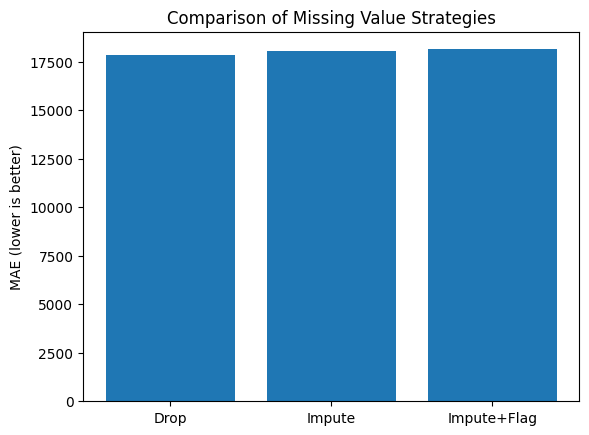

In [10]:
import matplotlib.pyplot as plt

plt.bar(["Drop", "Impute", "Impute+Flag"], [mae_drop, mae_impute, mae_plus])
plt.ylabel("MAE (lower is better)")
plt.title("Comparison of Missing Value Strategies")
plt.show()

### 🧠 Conclusão + Quando Usar Cada Técnica

> Conclusão

- Simple Imputation teve o melhor desempenho.
- Drop Columns removeu informação demais.
- Missingness Indicators não ajudaram neste dataset.

> Quando usar cada abordagem?

- **Drop Columns:** coluna quase vazia.
- **Simple Imputation:** caso geral, melhor escolha.
- **Imputation + Indicators:** quando a ausência tem significado.
